In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Marketing_Campaign_Data.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset loaded successfully!
Shape: (763, 13)

Columns:
['Date', 'CampaignID', 'CampaignName', 'Platform', 'TargetAudience', 'Impressions', 'Clicks', 'Leads', 'Applications', 'Enrollments', 'Cost (₹)', 'Revenue (₹)', 'Region']


In [5]:
# Basic information about the dataset

print("First 5 rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe(include="all").T)

First 5 rows:


,Date,CampaignID,CampaignName,Platform,TargetAudience,Impressions,Clicks,Leads,Applications,Enrollments,Cost (₹),Revenue (₹),Region
0,2024-01-01,AD004,Hackathon,YouTube,17–21 Age,285708,16956,4087,2547,1148,275457.87,4615838.04,West India
1,2024-01-02,AD004,Hackathon,YouTube,17–21 Age,140449,10082,1815,951,565,133025.86,3513169.90,North India
2,2024-01-03,AD004,Hackathon,YouTube,17–21 Age,140958,7474,1169,683,343,135765.61,1051924.88,North India
3,2024-01-04,AD004,Hackathon,YouTube,22–27 Age,257823,16841,3179,1584,698,229715.44,3850639.56,West India
4,2024-01-05,AD004,Hackathon,YouTube,25–35 Age,98595,7293,1340,854,368,52360.96,1543262.86,West India



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 763 entries, 0 to 762
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            763 non-null    datetime64[us]
 1   CampaignID      763 non-null    str           
 2   CampaignName    763 non-null    str           
 3   Platform        763 non-null    str           
 4   TargetAudience  763 non-null    str           
 5   Impressions     763 non-null    int64         
 6   Clicks          763 non-null    int64         
 7   Leads           763 non-null    int64         
 8   Applications    763 non-null    int64         
 9   Enrollments     763 non-null    int64         
 10  Cost (₹)        763 non-null    float64       
 11  Revenue (₹)     763 non-null    float64       
 12  Region          763 non-null    str           
dtypes: datetime64[us](1), float64(2), int64(5), str(5)
memory usage: 77.6 KB

Missing Values:
Date     

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Date,763,NaN,NaN,NaN,2024-11-22 09:28:04.403669,2024-01-01 00:00:00,2024-06-08 12:00:00,2024-11-15 00:00:00,2025-05-12 12:00:00,2025-10-31 00:00:00,NaN
CampaignID,763,5,AD001,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CampaignName,763,5,UG Admission,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Platform,763,5,Google Ads,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TargetAudience,763,4,17–21 Age,316,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Impressions,763.0,NaN,NaN,NaN,169276.78768,50267.0,106156.0,166847.0,232192.5,299910.0,73046.934246
Clicks,763.0,NaN,NaN,NaN,9355.716907,1674.0,5448.0,8435.0,12587.5,23654.0,4949.433462
Leads,763.0,NaN,NaN,NaN,1862.757536,327.0,1085.5,1684.0,2496.0,5219.0,1007.799358
Applications,763.0,NaN,NaN,NaN,1027.019659,159.0,589.0,909.0,1365.0,3112.0,574.587368
Enrollments,763.0,NaN,NaN,NaN,514.173001,73.0,291.5,451.0,682.0,1664.0,294.810151


In [6]:
# Make a copy for cleaning
cleaned_df = df.copy()

# Remove duplicate rows
cleaned_df = cleaned_df.drop_duplicates()

# Convert Date column to datetime
cleaned_df["Date"] = pd.to_datetime(cleaned_df["Date"], errors="coerce")

# Display missing values after cleaning
print("Missing values:")
print(cleaned_df.isnull().sum())

print("\nShape after cleaning:", cleaned_df.shape)

Missing values:
Date              0
CampaignID        0
CampaignName      0
Platform          0
TargetAudience    0
Impressions       0
Clicks            0
Leads             0
Applications      0
Enrollments       0
Cost (₹)          0
Revenue (₹)       0
Region            0
dtype: int64

Shape after cleaning: (763, 13)


In [7]:
# Save cleaned dataset
cleaned_df.to_csv("Marketing_Campaign_Cleaned.csv", index=False)

print("Marketing_Campaign_Cleaned.csv created successfully!")

Marketing_Campaign_Cleaned.csv created successfully!


In [8]:
print(cleaned_df.columns.tolist())

['Date', 'CampaignID', 'CampaignName', 'Platform', 'TargetAudience', 'Impressions', 'Clicks', 'Leads', 'Applications', 'Enrollments', 'Cost (₹)', 'Revenue (₹)', 'Region']


In [9]:
for i, col in enumerate(cleaned_df.columns, 1):
    print(i, ":", col)

1 : Date
2 : CampaignID
3 : CampaignName
4 : Platform
5 : TargetAudience
6 : Impressions
7 : Clicks
8 : Leads
9 : Applications
10 : Enrollments
11 : Cost (₹)
12 : Revenue (₹)
13 : Region


In [10]:
import os

os.makedirs("Graphs", exist_ok=True)

print("Graphs folder is ready!")

Graphs folder is ready!


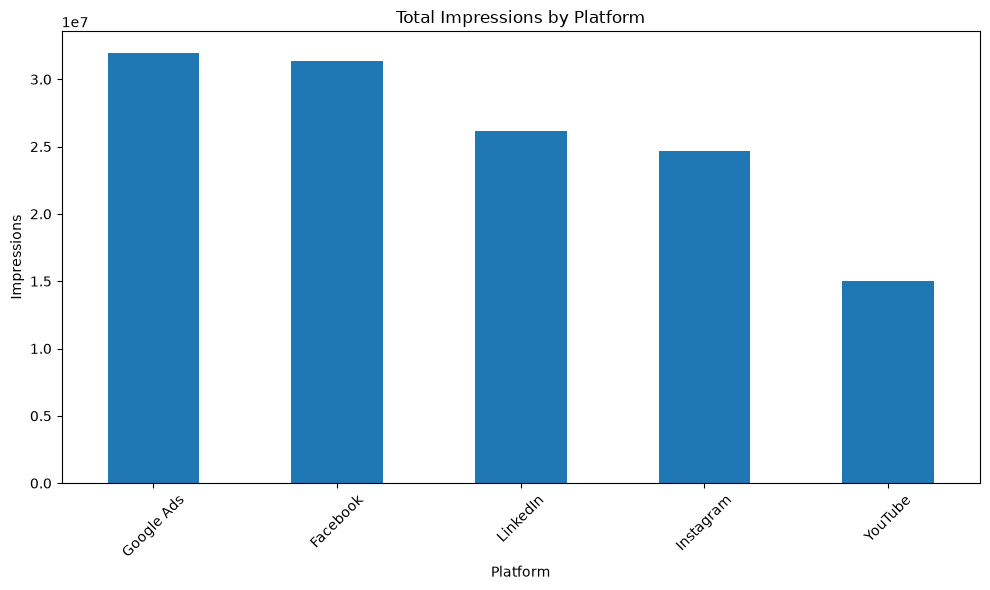

In [11]:
# 1. Impressions by Platform

platform_impressions = cleaned_df.groupby("Platform")["Impressions"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_impressions.plot(kind="bar")
plt.title("Total Impressions by Platform")
plt.xlabel("Platform")
plt.ylabel("Impressions")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/01_Impressions_by_Platform.png", dpi=300)
plt.show()

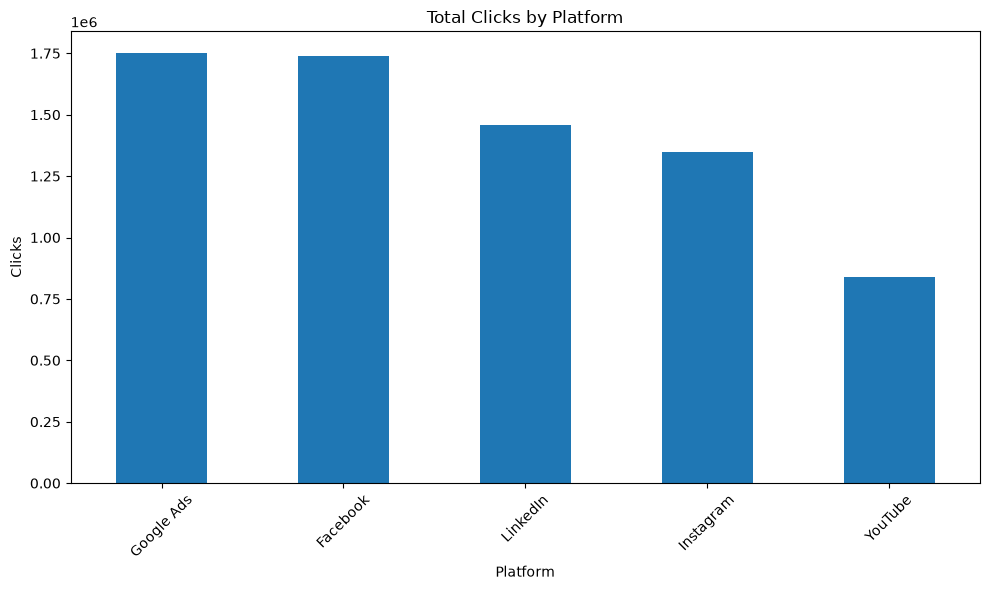

In [12]:
# 2. Clicks by Platform

platform_clicks = cleaned_df.groupby("Platform")["Clicks"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_clicks.plot(kind="bar")
plt.title("Total Clicks by Platform")
plt.xlabel("Platform")
plt.ylabel("Clicks")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/02_Clicks_by_Platform.png", dpi=300)
plt.show()

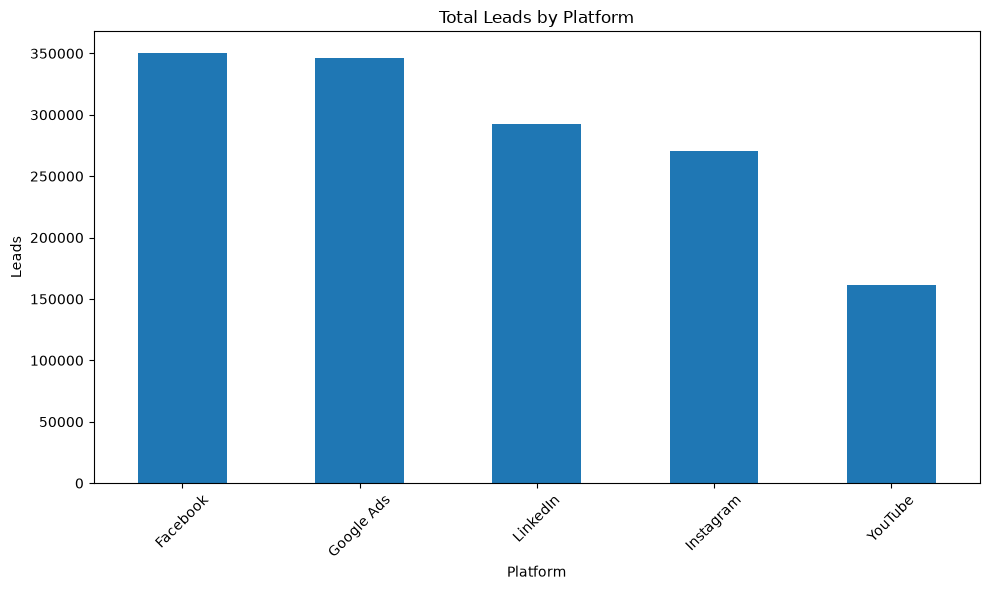

In [13]:
# 3. Leads by Platform

platform_leads = cleaned_df.groupby("Platform")["Leads"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_leads.plot(kind="bar")
plt.title("Total Leads by Platform")
plt.xlabel("Platform")
plt.ylabel("Leads")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/03_Leads_by_Platform.png", dpi=300)
plt.show()

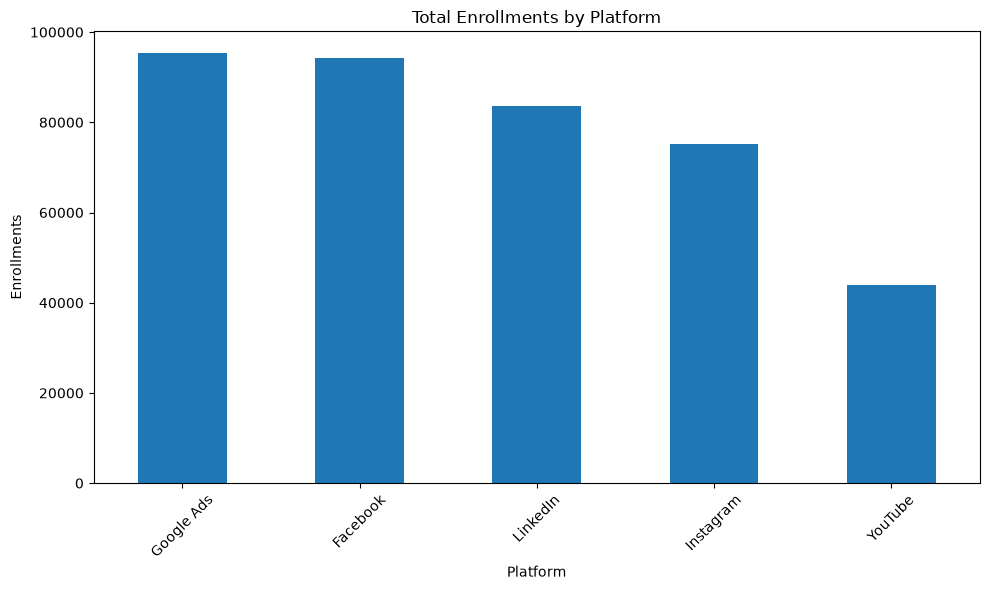

In [14]:
# 4. Enrollments by Platform

platform_enrollments = cleaned_df.groupby("Platform")["Enrollments"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_enrollments.plot(kind="bar")
plt.title("Total Enrollments by Platform")
plt.xlabel("Platform")
plt.ylabel("Enrollments")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/04_Enrollments_by_Platform.png", dpi=300)
plt.show()

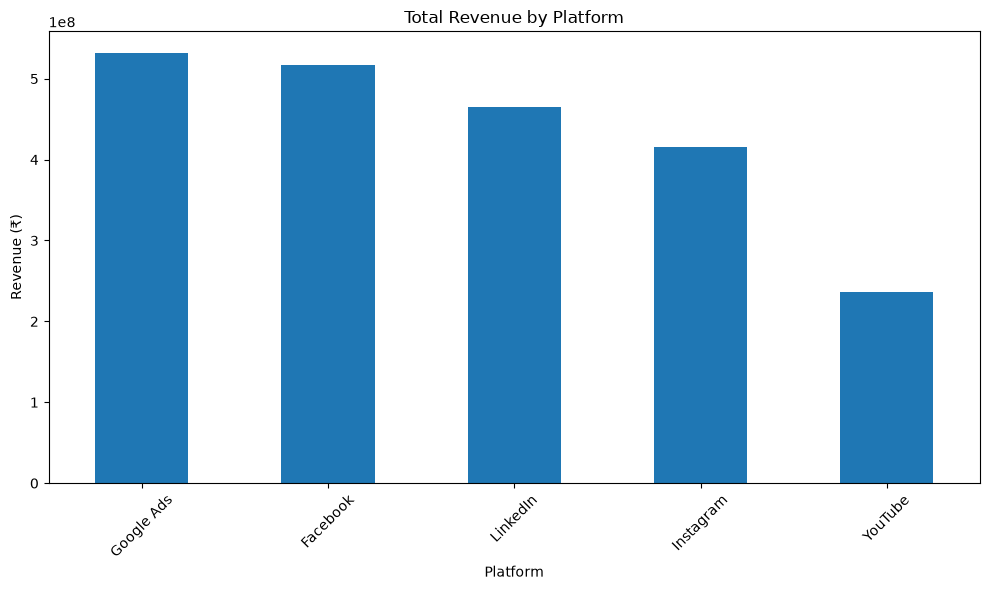

In [15]:
# 5. Revenue by Platform

platform_revenue = cleaned_df.groupby("Platform")["Revenue (₹)"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_revenue.plot(kind="bar")
plt.title("Total Revenue by Platform")
plt.xlabel("Platform")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/05_Revenue_by_Platform.png", dpi=300)
plt.show()

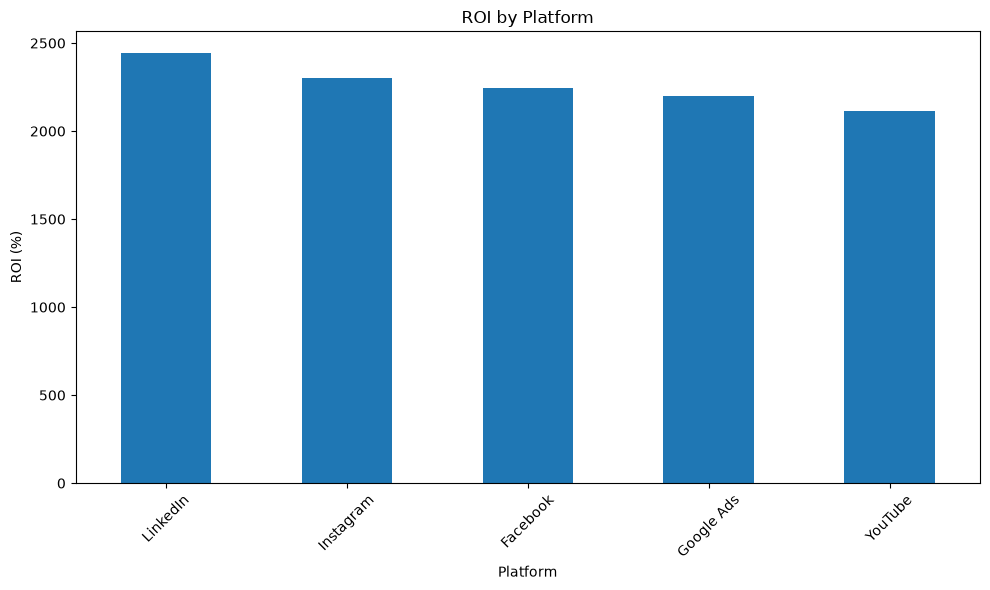

In [16]:
# 6. ROI by Platform

platform_roi = (
    cleaned_df.groupby("Platform")
    .agg({"Revenue (₹)": "sum", "Cost (₹)": "sum"})
)

platform_roi["ROI (%)"] = (
    (platform_roi["Revenue (₹)"] - platform_roi["Cost (₹)"])
    / platform_roi["Cost (₹)"]
) * 100

platform_roi = platform_roi["ROI (%)"].sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_roi.plot(kind="bar")
plt.title("ROI by Platform")
plt.xlabel("Platform")
plt.ylabel("ROI (%)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/06_ROI_by_Platform.png", dpi=300)
plt.show()

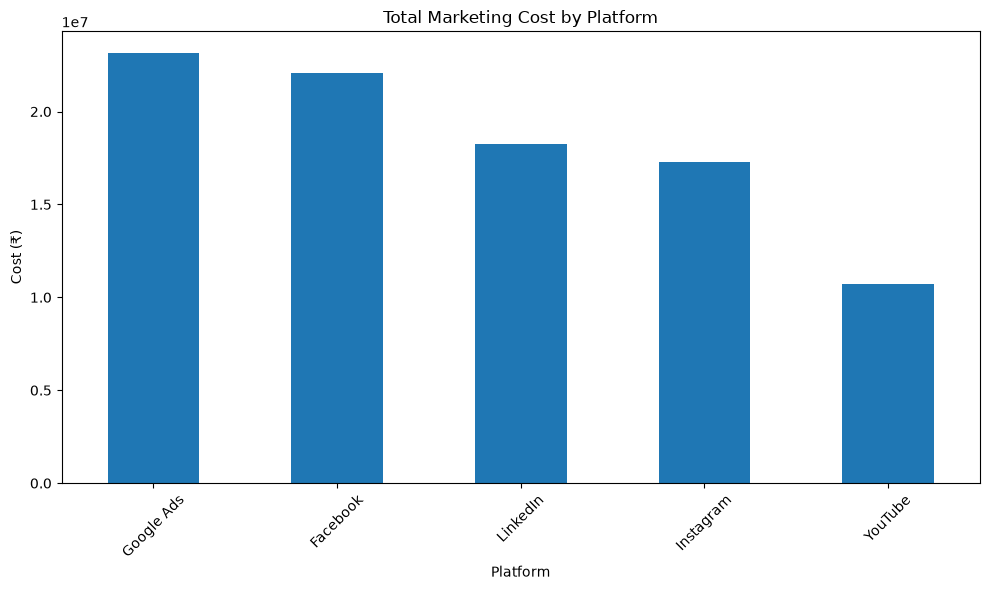

In [17]:
# 7. Cost by Platform

platform_cost = cleaned_df.groupby("Platform")["Cost (₹)"].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
platform_cost.plot(kind="bar")
plt.title("Total Marketing Cost by Platform")
plt.xlabel("Platform")
plt.ylabel("Cost (₹)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Graphs/07_Cost_by_Platform.png", dpi=300)
plt.show()

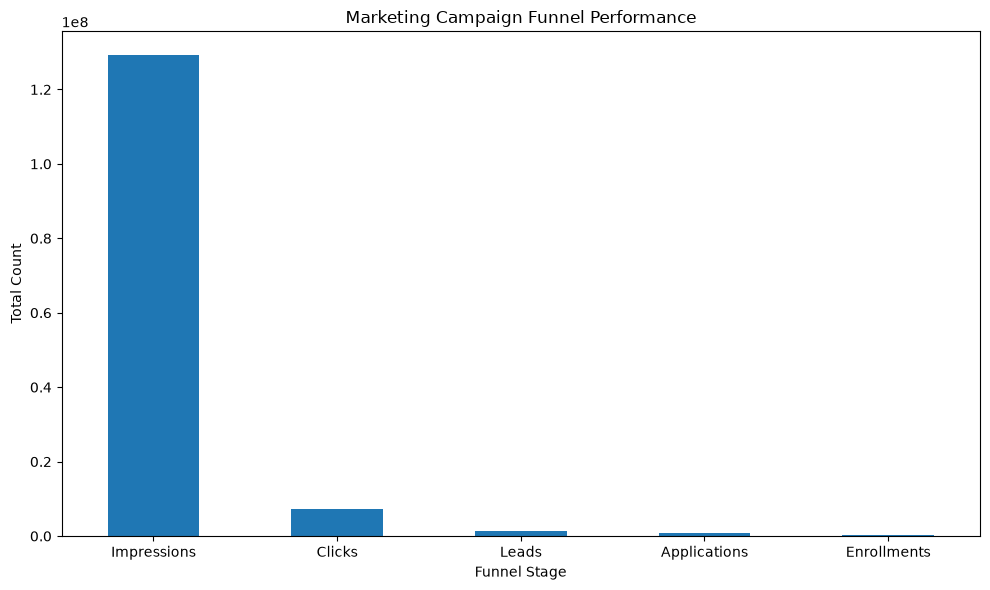

In [18]:
# 8. Marketing Funnel Performance

funnel = {
    "Impressions": cleaned_df["Impressions"].sum(),
    "Clicks": cleaned_df["Clicks"].sum(),
    "Leads": cleaned_df["Leads"].sum(),
    "Applications": cleaned_df["Applications"].sum(),
    "Enrollments": cleaned_df["Enrollments"].sum()
}

funnel_series = pd.Series(funnel)

plt.figure(figsize=(10, 6))
funnel_series.plot(kind="bar")
plt.title("Marketing Campaign Funnel Performance")
plt.xlabel("Funnel Stage")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("Graphs/08_Marketing_Funnel.png", dpi=300)
plt.show()

In [19]:
# Key Marketing Performance Metrics

total_impressions = cleaned_df["Impressions"].sum()
total_clicks = cleaned_df["Clicks"].sum()
total_leads = cleaned_df["Leads"].sum()
total_applications = cleaned_df["Applications"].sum()
total_enrollments = cleaned_df["Enrollments"].sum()
total_cost = cleaned_df["Cost (₹)"].sum()
total_revenue = cleaned_df["Revenue (₹)"].sum()

ctr = (total_clicks / total_impressions) * 100
lead_conversion = (total_leads / total_clicks) * 100
application_conversion = (total_applications / total_leads) * 100
enrollment_conversion = (total_enrollments / total_applications) * 100
roi = ((total_revenue - total_cost) / total_cost) * 100
cost_per_lead = total_cost / total_leads
cost_per_enrollment = total_cost / total_enrollments

print("===== MARKETING CAMPAIGN PERFORMANCE =====")
print(f"Total Impressions: {total_impressions:,.0f}")
print(f"Total Clicks: {total_clicks:,.0f}")
print(f"Total Leads: {total_leads:,.0f}")
print(f"Total Applications: {total_applications:,.0f}")
print(f"Total Enrollments: {total_enrollments:,.0f}")
print(f"Total Cost: ₹{total_cost:,.2f}")
print(f"Total Revenue: ₹{total_revenue:,.2f}")
print(f"CTR: {ctr:.2f}%")
print(f"Lead Conversion Rate: {lead_conversion:.2f}%")
print(f"Application Conversion Rate: {application_conversion:.2f}%")
print(f"Enrollment Conversion Rate: {enrollment_conversion:.2f}%")
print(f"Overall ROI: {roi:.2f}%")
print(f"Cost per Lead: ₹{cost_per_lead:.2f}")
print(f"Cost per Enrollment: ₹{cost_per_enrollment:.2f}")

===== MARKETING CAMPAIGN PERFORMANCE =====
Total Impressions: 129,158,189
Total Clicks: 7,138,412
Total Leads: 1,421,284
Total Applications: 783,616
Total Enrollments: 392,314
Total Cost: ₹91,448,131.19
Total Revenue: ₹2,165,462,575.20
CTR: 5.53%
Lead Conversion Rate: 19.91%
Application Conversion Rate: 55.13%
Enrollment Conversion Rate: 50.06%
Overall ROI: 2267.97%
Cost per Lead: ₹64.34
Cost per Enrollment: ₹233.10


In [20]:
# Platform Performance Summary

platform_summary = cleaned_df.groupby("Platform").agg({
    "Impressions": "sum",
    "Clicks": "sum",
    "Leads": "sum",
    "Applications": "sum",
    "Enrollments": "sum",
    "Cost (₹)": "sum",
    "Revenue (₹)": "sum"
})

platform_summary["CTR (%)"] = (
    platform_summary["Clicks"] / platform_summary["Impressions"]
) * 100

platform_summary["ROI (%)"] = (
    (platform_summary["Revenue (₹)"] - platform_summary["Cost (₹)"])
    / platform_summary["Cost (₹)"]
) * 100

platform_summary["Cost per Enrollment (₹)"] = (
    platform_summary["Cost (₹)"] / platform_summary["Enrollments"]
)

platform_summary = platform_summary.sort_values(
    "ROI (%)", ascending=False
)

platform_summary.round(2)

,Impressions,Clicks,Leads,Applications,Enrollments,Cost (₹),Revenue (₹),CTR (%),ROI (%),Cost per Enrollment (₹)
Platform,,,,,,,,,,
LinkedIn,26146791,1460099,292161,163739,83522,18258974.94,4.646099e+08,5.58,2444.56,218.61
Instagram,24699279,1347998,270522,148302,75249,17285042.28,4.149747e+08,5.46,2300.77,229.70
Facebook,31329302,1740443,350452,191054,94199,22051324.43,5.172759e+08,5.56,2245.78,234.09
Google Ads,31963554,1751859,346441,190327,95402,23158075.68,5.319735e+08,5.48,2197.14,242.74
YouTube,15019263,838013,161708,90194,43942,10694713.86,2.366285e+08,5.58,2112.57,243.38


In [21]:
# Business Insights & Recommendations

best_roi_platform = platform_summary["ROI (%)"].idxmax()
lowest_cost_platform = platform_summary["Cost per Enrollment (₹)"].idxmin()
highest_revenue_platform = platform_summary["Revenue (₹)"].idxmax()
highest_enrollment_platform = platform_summary["Enrollments"].idxmax()

print("===== BUSINESS INSIGHTS =====")

print(f"1. {best_roi_platform} has the highest ROI of "
      f"{platform_summary.loc[best_roi_platform, 'ROI (%)']:.2f}%.")

print(f"2. {lowest_cost_platform} has the lowest cost per enrollment of "
      f"₹{platform_summary.loc[lowest_cost_platform, 'Cost per Enrollment (₹)']:.2f}.")

print(f"3. {highest_revenue_platform} generates the highest total revenue "
      f"of ₹{platform_summary.loc[highest_revenue_platform, 'Revenue (₹)']:,.2f}.")

print(f"4. {highest_enrollment_platform} has the highest number of enrollments "
      f"with {platform_summary.loc[highest_enrollment_platform, 'Enrollments']:,.0f} enrollments.")

print("\n===== RECOMMENDATIONS =====")
print("• Increase investment in high-ROI platforms.")
print("• Maintain strong-performing platforms with high revenue and enrollments.")
print("• Review low-performing platforms and improve their cost efficiency.")
print("• Optimize the marketing funnel to improve conversions at each stage.")
print("• Focus on improving click-to-lead and application-to-enrollment conversion rates.")

===== BUSINESS INSIGHTS =====
1. LinkedIn has the highest ROI of 2444.56%.
2. LinkedIn has the lowest cost per enrollment of ₹218.61.
3. Google Ads generates the highest total revenue of ₹531,973,533.88.
4. Google Ads has the highest number of enrollments with 95,402 enrollments.

===== RECOMMENDATIONS =====
• Increase investment in high-ROI platforms.
• Maintain strong-performing platforms with high revenue and enrollments.
• Review low-performing platforms and improve their cost efficiency.
• Optimize the marketing funnel to improve conversions at each stage.
• Focus on improving click-to-lead and application-to-enrollment conversion rates.


In [22]:
# Conclusion

print("""
===== CONCLUSION =====

The marketing campaign analysis provides valuable insights into
platform performance, customer engagement, conversion rates, and ROI.

The analysis shows that different marketing platforms perform
differently across the campaign funnel. Platforms with higher ROI
and lower cost per enrollment should receive greater attention,
while lower-performing channels should be reviewed for cost
optimization.

Overall, improving funnel conversion rates and allocating budget
towards efficient platforms can help increase enrollments and
improve marketing campaign profitability.
""")


===== CONCLUSION =====

The marketing campaign analysis provides valuable insights into
platform performance, customer engagement, conversion rates, and ROI.

The analysis shows that different marketing platforms perform
differently across the campaign funnel. Platforms with higher ROI
and lower cost per enrollment should receive greater attention,
while lower-performing channels should be reviewed for cost
optimization.

Overall, improving funnel conversion rates and allocating budget
towards efficient platforms can help increase enrollments and
improve marketing campaign profitability.

